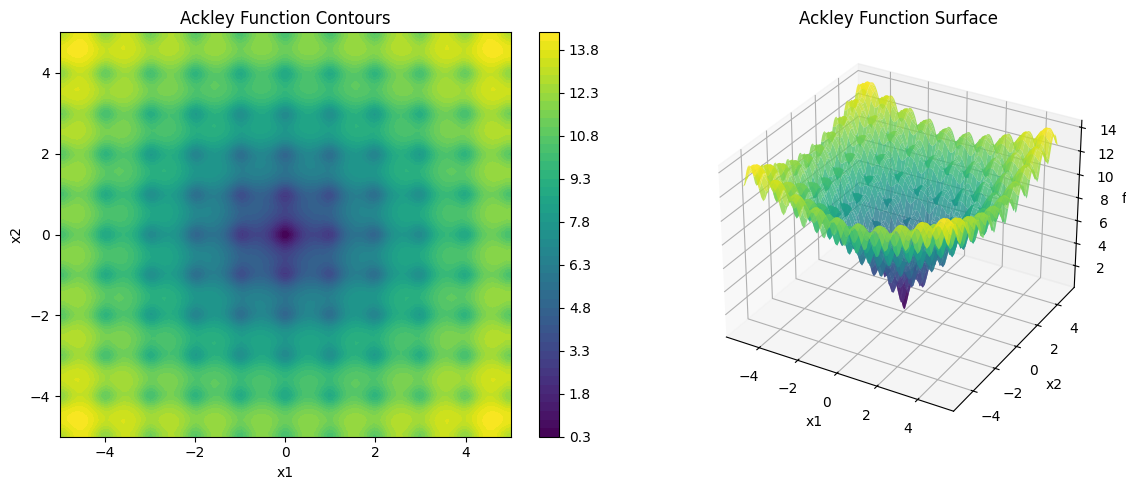

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.optimize import minimize, differential_evolution
from skopt import gp_minimize
from skopt.space import Real
import time



def ackley(x):
    """
    Ackley function - classic multimodal benchmark.
    Global minimum: f(0,0) = 0.
    
    Parameters:
    -----------
    x : array-like of length 2
    
    Returns:
    --------
    float : function value
    """
    x = np.asarray(x)
    a, b, c = 20.0, 0.2, 2 * np.pi
    d = len(x)
    
    sum_sq = np.sum(x**2)
    sum_cos = np.sum(np.cos(c * x))
    
    term1 = -a * np.exp(-b * np.sqrt(sum_sq / d))
    term2 = -np.exp(sum_cos / d)
    
    return term1 + term2 + a + np.e


# Visualization of the Ackley surface
def plot_ackley_surface():
    x = np.linspace(-5, 5, 100)
    y = np.linspace(-5, 5, 100)
    X, Y = np.meshgrid(x, y)
    Z = np.array([ackley(np.array([xi, yi])) for xi, yi in zip(X.ravel(), Y.ravel())]).reshape(X.shape)
    
    fig = plt.figure(figsize=(12, 5))
    
    # 2D contour
    ax1 = fig.add_subplot(121)
    contour = ax1.contourf(X, Y, Z, levels=50, cmap='viridis')
    ax1.set_xlabel('x1')
    ax1.set_ylabel('x2')
    ax1.set_title('Ackley Function Contours')
    plt.colorbar(contour, ax=ax1)
    
    # 3D surface
    ax2 = fig.add_subplot(122, projection='3d')
    surf = ax2.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)
    ax2.set_xlabel('x1')
    ax2.set_ylabel('x2')
    ax2.set_zlabel('f(x)')
    ax2.set_title('Ackley Function Surface')
    
    plt.tight_layout()
    plt.show()

plot_ackley_surface()

In [10]:
def differential_evolution(fobj, bounds, mut=0.8, crossp=0.7, popsize=20, its=1000, seed=None):
    """
    Differential Evolution implementation (rand/1/bin strategy).
    
    Parameters:
    -----------
    fobj : callable
        Objective function to minimize
    bounds : list of tuples
        [(low1, high1), (low2, high2), ...] for each dimension
    mut : float
        Mutation factor (F) - controls differential variation
    crossp : float
        Crossover probability (CR) - probability of inheriting from mutant
    popsize : int
        Population size (NP) - number of candidate solutions
    its : int
        Maximum number of generations
    seed : int or None
        Random seed for reproducibility
    
    Returns:
    --------
    generator : yields (best_solution, best_fitness, generation, eval_count)
    """
    if seed is not None:
        np.random.seed(seed)
    
    dimensions = len(bounds)
    # Initialize population
    pop = np.random.rand(popsize, dimensions)
    # Scale to bounds
    min_b, max_b = np.asarray(bounds).T
    diff = np.fabs(min_b - max_b)
    pop_denorm = min_b + pop * diff
    # Evaluate initial population
    fitness = np.asarray([fobj(ind) for ind in pop_denorm])
    best_idx = np.argmin(fitness)
    best = pop_denorm[best_idx]
    best_fitness = fitness[best_idx]
    eval_count = popsize
    
    yield best, best_fitness, 0, eval_count
    
    for i in range(its):
        for j in range(popsize):
            # Mutation: choose 3 distinct random vectors different from j
            idxs = [idx for idx in range(popsize) if idx != j]
            a, b, c = pop[np.random.choice(idxs, 3, replace=False)]
            
            # Donor vector (mutant)
            mutant = np.clip(a + mut * (b - c), 0, 1)
            
            # Crossover: create trial vector
            cross_points = np.random.rand(dimensions) < crossp
            if not np.any(cross_points):
                cross_points[np.random.randint(0, dimensions)] = True
            trial = np.where(cross_points, mutant, pop[j])
            
            # Denormalize and evaluate trial
            trial_denorm = min_b + trial * diff
            f_trial = fobj(trial_denorm)
            eval_count += 1
            
            # Selection: greedy replacement
            if f_trial < fitness[j]:
                fitness[j] = f_trial
                pop[j] = trial
                if f_trial < best_fitness:
                    best = trial_denorm
                    best_fitness = f_trial
        
        yield best, best_fitness, i+1, eval_count


# Helper function to run DE and collect results
def run_de(fobj, bounds, max_evals=500, **kwargs):
    """Run DE and return final solution, fitness, and convergence history."""
    history = []
    de_gen = differential_evolution(fobj, bounds, **kwargs)
    final_best, final_fitness = None, None
    total_evals = 0
    
    for best, fitness, gen, evals in de_gen:
        # print(best, gen, evals, fitness)
        total_evals = evals
        history.append((gen, evals, fitness, best))
        final_best, final_fitness = best, fitness
        if evals >= max_evals:
            break
    
    return final_best, final_fitness, history


# Quick test: minimize simple quadratic to verify DE works
bounds = [(-5, 5), (-5, 5)]
print("Testing DE on Ackley (quick run):")
test_best, test_fitness, _ = run_de(ackley, bounds, max_evals=200, its=100, popsize=10, seed=42)
print(f"  Best solution: {test_best}")
print(f"  Best fitness:  {test_fitness:.6f}")

Testing DE on Ackley (quick run):
  Best solution: [0.01584816 0.02115693]
  Best fitness:  0.093288


In [11]:
def gradient_descent(fobj, x0, learning_rate=0.01, max_iter=500, tol=1e-7):
    """
    Simple gradient descent with finite-difference gradient estimation.
    
    Parameters:
    -----------
    fobj : callable
        Objective function
    x0 : array
        Initial guess
    learning_rate : float
        Step size
    max_iter : int
        Maximum iterations
    tol : float
        Convergence tolerance
    
    Returns:
    --------
    dict with x, fun, n_iter, history, success
    """
    x = np.array(x0, dtype=float)
    dim = len(x)
    history = [(0, fobj(x), x.copy())]
    epsilon = 1e-8
    
    for iteration in range(max_iter):
        # Finite difference gradient
        grad = np.zeros(dim)
        f_current = fobj(x)
        
        for i in range(dim):
            x_plus = x.copy()
            x_plus[i] += epsilon
            grad[i] = (fobj(x_plus) - f_current) / epsilon
        
        # Update step
        x_new = x - learning_rate * grad
        f_new = fobj(x_new)
        history.append((iteration+1, f_new, x_new.copy()))
        
        # Check convergence
        if np.linalg.norm(grad) < tol or abs(f_new - f_current) < tol:
            break
        
        x = x_new
    
    return {
        'x': x,
        'fun': f_new,
        'n_iter': iteration + 1,
        'history': history,
        'success': iteration < max_iter - 1
    }


def run_gd(fobj, bounds, max_evals=500, n_restarts=5, learning_rate=0.01):
    """Run gradient descent with multiple random restarts."""
    best_x = None
    best_f = np.inf
    all_histories = []
    
    for restart in range(n_restarts):
        # Random initialization within bounds
        x0 = np.array([np.random.uniform(low, high) for low, high in bounds])
        result = gradient_descent(fobj, x0, learning_rate=learning_rate, max_iter=max_evals)
        
        all_histories.append(result['history'])
        if result['fun'] < best_f:
            best_f = result['fun']
            best_x = result['x']
    
    return best_x, best_f, all_histories

In [12]:
def random_search(fobj, bounds, max_evals=500, seed=None):
    """
    Pure random search baseline.
    
    Parameters:
    -----------
    fobj : callable
        Objective function
    bounds : list of tuples
        [(low1, high1), (low2, high2), ...]
    max_evals : int
        Maximum number of function evaluations
    seed : int or None
        Random seed
    
    Returns:
    --------
    best_x, best_f, history (list of (eval_count, fitness, x))
    """
    if seed is not None:
        np.random.seed(seed)
    
    dim = len(bounds)
    best_x = None
    best_f = np.inf
    history = []
    
    for i in range(max_evals):
        # Sample random point within bounds
        x = np.array([np.random.uniform(low, high) for low, high in bounds])
        f_val = fobj(x)
        history.append((i+1, f_val, x.copy()))
        
        if f_val < best_f:
            best_f = f_val
            best_x = x
    
    return best_x, best_f, history

In [13]:
def run_bayesian_optimization(fobj, bounds, max_evals=5, random_state=42):
    """
    Bayesian Optimization using Gaussian Processes.
    
    Parameters:
    -----------
    fobj : callable
        Objective function (must accept a list or array and return float)
    bounds : list of tuples
        [(low1, high1), (low2, high2)]
    max_evals : int
        Maximum number of function evaluations
    random_state : int
        Random seed

    Returns:
    --------
    best_x : list
        Best solution found
    best_f : float
        Best function value
    history : list of (eval_count, f_val)
        Convergence history
    """
    # Define search space
    space = [Real(low, high, name=f'x{i}') for i, (low, high) in enumerate(bounds)]
    
    # Track history
    history = []
    eval_count = 0
    
    def safe_objective(x):
        """Wrapper that converts list to array if needed and records history."""
        nonlocal eval_count
        eval_count += 1
        # fobj should handle list input; our ackley uses np.asarray(x) inside
        f_val = fobj(x)
        history.append((eval_count, f_val))
        return f_val
    
    # Run Bayesian optimization
    result = gp_minimize(
        safe_objective,
        space,
        n_calls=max_evals,
        random_state=random_state,
        n_initial_points=10,      # number of random points before GP model
        acq_func='EI',            # Expected Improvement
        verbose=False
    )
    
    # Result is a scipy OptimizeResult-like object
    best_x = result.x      # list of coordinates
    best_f = result.fun    # best function value
    
    return best_x, best_f, history

In [14]:
# ============================================================
# Run All Optimizers Under Fair Conditions
# ============================================================

# Common settings
bounds = [(-5, 5), (-5, 5)]
max_evaluations = 500
seed = 42

print("=" * 60)
print("BENCHMARK: 2D ACKLEY FUNCTION")
print(f"Function evaluations budget: {max_evaluations}")
print("=" * 60)

# 1. Differential Evolution
print("\n[1] Running Differential Evolution...")
start_time = time.time()
de_best, de_fitness, de_history = run_de(
    ackley, bounds, max_evals=max_evaluations, 
    mut=0.8, crossp=0.7, popsize=20, its=100, seed=seed
)
de_time = time.time() - start_time
print(f"    ✓ Best solution: [{de_best[0]:.6f}, {de_best[1]:.6f}]")
print(f"    ✓ Best fitness:  {de_fitness:.10f}")
print(f"    ✓ Time:          {de_time:.4f}s")

# 2. Gradient Descent
print("\n[2] Running Gradient Descent (with 5 random restarts)...")
start_time = time.time()
gd_best, gd_fitness, gd_histories = run_gd(
    ackley, bounds, max_evals=max_evaluations, 
    n_restarts=5, learning_rate=0.001
)
gd_time = time.time() - start_time
print(f"    ✓ Best solution: [{gd_best[0]:.6f}, {gd_best[1]:.6f}]")
print(f"    ✓ Best fitness:  {gd_fitness:.10f}")
print(f"    ✓ Time:          {gd_time:.4f}s")

# 3. Random Search
print("\n[3] Running Random Search...")
start_time = time.time()
rs_best, rs_fitness, rs_history = random_search(
    ackley, bounds, max_evals=max_evaluations, seed=seed
)
rs_time = time.time() - start_time
print(f"    ✓ Best solution: [{rs_best[0]:.6f}, {rs_best[1]:.6f}]")
print(f"    ✓ Best fitness:  {rs_fitness:.10f}")
print(f"    ✓ Time:          {rs_time:.4f}s")

# 4. Bayesian Optimization
print("\n[4] Running Bayesian Optimization...")
start_time = time.time()
bo_best, bo_fitness, bo_history = run_bayesian_optimization(
    ackley, bounds, max_evals=max_evaluations//50, random_state=seed
)
bo_time = time.time() - start_time
print(f"    ✓ Best solution: [{bo_best[0]:.6f}, {bo_best[1]:.6f}]")
print(f"    ✓ Best fitness:  {bo_fitness:.10f}")
print(f"    ✓ Time:          {bo_time:.4f}s")

BENCHMARK: 2D ACKLEY FUNCTION
Function evaluations budget: 500

[1] Running Differential Evolution...
    ✓ Best solution: [0.017909, -0.011892]
    ✓ Best fitness:  0.0730727604
    ✓ Time:          0.0266s

[2] Running Gradient Descent (with 5 random restarts)...
    ✓ Best solution: [-0.000142, 0.952047]
    ✓ Best fitness:  2.5799283567
    ✓ Time:          0.0423s

[3] Running Random Search...
    ✓ Best solution: [0.113424, 0.015163]
    ✓ Best fitness:  0.6379615463
    ✓ Time:          0.0092s

[4] Running Bayesian Optimization...
    ✓ Best solution: [-0.407511, -1.662914]
    ✓ Best fitness:  6.5116004635
    ✓ Time:          0.2269s


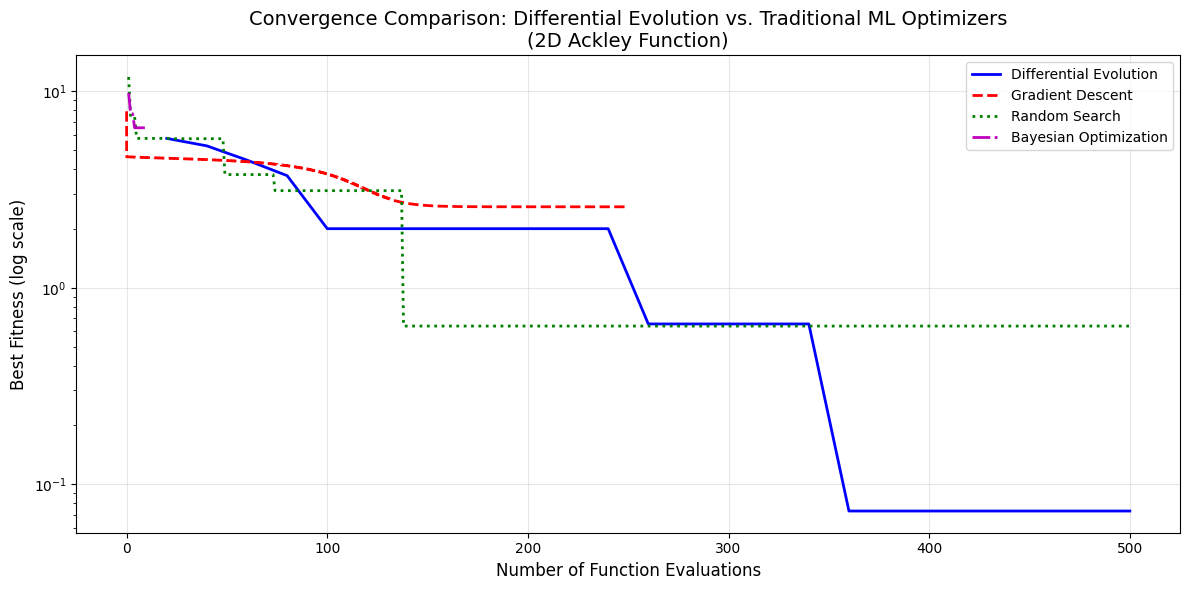

In [22]:

de_evals = [evals for _, evals, _, _ in de_history]   # list of integers
de_values = [f for _, _, f, _ in de_history]          # list of floats
de_bests = [b for _, _, _, b in de_history]          # list of floats

# de_evals = [evals for _, evals, _ in de_history]
# de_values = [f for _, _, f in de_history]

gd_best_vals = []
for hist in gd_histories:
    for evals, f_val, _ in hist:
        gd_best_vals.append((evals, f_val))
# Take best-so-far
gd_best_vals_sorted = sorted(gd_best_vals, key=lambda x: x[0])
gd_best_so_far = []
current_best = np.inf
for evals, f_val in gd_best_vals_sorted:
    if f_val < current_best:
        current_best = f_val
    gd_best_so_far.append((evals, current_best))

rs_evals = [e for e, _, _ in rs_history]
rs_best_so_far = []
current_best = np.inf
for e, f_val, _ in rs_history:
    if f_val < current_best:
        current_best = f_val
    rs_best_so_far.append((e, current_best))

bo_evals = [e for e, _ in bo_history]
bo_best_so_far = []
current_best = np.inf
for e, f_val in bo_history:
    if f_val < current_best:
        current_best = f_val
    bo_best_so_far.append((e, current_best))

# print(gd_best_so_far, gd_best)

# For Gradient Descent, Random Search, Bayesian Optimization, we need best‑so‑far curves:
# (These should have been built as lists of (evaluation_count, best_fitness_so_far))

plt.figure(figsize=(12, 6))

# Differential Evolution – x = de_evals, y = de_values (already best‑so‑far because DE keeps global best)
plt.semilogy(de_evals, de_values, 'b-', linewidth=2, label='Differential Evolution')

# Gradient Descent (with multiple restarts) – gd_best_so_far is list of (eval, best)
if len(gd_best_so_far) > 0:
    plt.semilogy([e for e, _ in gd_best_so_far], [f for _, f in gd_best_so_far], 'r--', linewidth=2, label='Gradient Descent')

# Random Search – rs_best_so_far list of (eval, best)
plt.semilogy([e for e, _ in rs_best_so_far], [f for _, f in rs_best_so_far], 'g:', linewidth=2, label='Random Search')

# Bayesian Optimization – bo_best_so_far list of (eval, best)
plt.semilogy([e for e, _ in bo_best_so_far], [f for _, f in bo_best_so_far], 'm-.', linewidth=2, label='Bayesian Optimization')

plt.xlabel('Number of Function Evaluations', fontsize=12)
plt.ylabel('Best Fitness (log scale)', fontsize=12)
plt.title('Convergence Comparison: Differential Evolution vs. Traditional ML Optimizers\n(2D Ackley Function)', fontsize=14)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

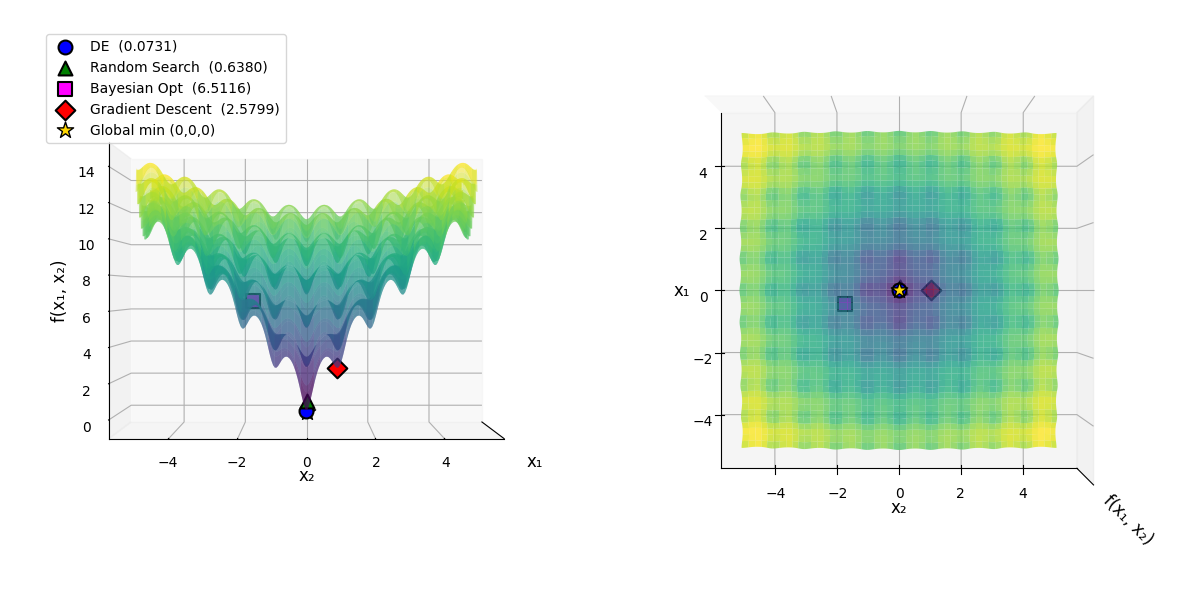

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ------------------------------------------------------------
# 1. Define Ackley function
# ------------------------------------------------------------
def ackley(x):
    x = np.asarray(x)
    a, b, c = 20.0, 0.2, 2 * np.pi
    d = len(x)
    sum_sq = np.sum(x**2)
    sum_cos = np.sum(np.cos(c * x))
    term1 = -a * np.exp(-b * np.sqrt(sum_sq / d))
    term2 = -np.exp(sum_cos / d)
    return term1 + term2 + a + np.e

# ------------------------------------------------------------
# 2. Create mesh
# ------------------------------------------------------------
x_vals = np.linspace(-5, 5, 200)
y_vals = np.linspace(-5, 5, 200)
X, Y = np.meshgrid(x_vals, y_vals)
Z = np.array([[ackley([x, y]) for x in x_vals] for y in y_vals])

# ------------------------------------------------------------
# 3. Final solutions (replace with your actual variable names)
# ------------------------------------------------------------
de_solution = de_best      # e.g. [0.000, 0.000]
rs_solution = rs_best      # e.g. [-0.012, 0.051]
bo_solution = bo_best      # e.g. [0.000, 0.000]
gd_solution = gd_best      # from gradient descent (best of 5 restarts)

# Compute z‑values
de_z = ackley(de_solution)
rs_z = ackley(rs_solution)
bo_z = ackley(bo_solution)
gd_z = ackley(gd_solution)

# ------------------------------------------------------------
# 4. 3D plot with all four optimizers
# ------------------------------------------------------------
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(121, projection='3d')


# Surface
surf = ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.5, linewidth=0, antialiased=True)

# Points
ax.scatter(de_solution[0], de_solution[1], de_z,
           color='blue', s=100, marker='o', edgecolors='black', linewidth=1.5,
           label=f'DE  ({de_z:.4f})')
ax.scatter(rs_solution[0], rs_solution[1], rs_z,
           color='green', s=100, marker='^', edgecolors='black', linewidth=1.5,
           label=f'Random Search  ({rs_z:.4f})')
ax.scatter(bo_solution[0], bo_solution[1], bo_z,
           color='magenta', s=100, marker='s', edgecolors='black', linewidth=1.5,
           label=f'Bayesian Opt  ({bo_z:.4f})')
ax.scatter(gd_solution[0], gd_solution[1], gd_z,
           color='red', s=100, marker='D', edgecolors='black', linewidth=1.5,
           label=f'Gradient Descent  ({gd_z:.4f})')

# True global minimum
ax.scatter(0, 0, 0, color='gold', s=150, marker='*', edgecolors='black', linewidth=1,
           label='Global min (0,0,0)')

ax.set_xlabel('x₁', fontsize=12)
ax.set_ylabel('x₂', fontsize=12)
ax.set_zlabel('f(x₁, x₂)', fontsize=12)
# ax.set_title('Ackley function with final solutions from all optimizers', fontsize=14)
# ax.set_xlim([-1,1])

# fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='f(x)')
ax.legend(loc='upper left', bbox_to_anchor=(0.05, 0.97))
ax.set_xticks([])
ax.view_init(0, 0)

ax2 = fig.add_subplot(122, projection='3d')

## top view:
# Surface
surf = ax2.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8, linewidth=0, antialiased=True)

# Points
ax2.scatter(de_solution[0], de_solution[1], de_z,
           color='blue', s=100, marker='o', edgecolors='black', linewidth=1.5,
           label=f'DE  ({de_z:.4f})')
ax2.scatter(rs_solution[0], rs_solution[1], rs_z,
           color='green', s=100, marker='^', edgecolors='black', linewidth=1.5,
           label=f'Random Search  ({rs_z:.4f})')
ax2.scatter(bo_solution[0], bo_solution[1], bo_z,
           color='magenta', s=100, marker='s', edgecolors='black', linewidth=1.5,
           label=f'Bayesian Opt  ({bo_z:.4f})')
ax2.scatter(gd_solution[0], gd_solution[1], gd_z,
           color='red', s=100, marker='D', edgecolors='black', linewidth=1.5,
           label=f'Gradient Descent  ({gd_z:.4f})')

# True global minimum
ax2.scatter(0, 0, 0, color='gold', s=150, marker='*', edgecolors='black', linewidth=1,
           label='Global min (0,0,0)')

ax2.set_xlabel('x₁', fontsize=12)
ax2.set_ylabel('x₂', fontsize=12)
ax2.set_zlabel('f(x₁, x₂)', fontsize=12)
# ax2.set_title('Ackley function with final solutions from all optimizers', fontsize=14)
# ax.set_xlim([-1,1])
ax2.set_zticks([])

# fig.colorbar(surf, ax=ax2, shrink=0.5, aspect=10, label='f(x)')
# ax2.legend(loc='best', bbox_to_anchor=(0.05, 0.95))
ax2.view_init(-90, 0)


plt.tight_layout()
plt.show()

In [27]:
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import HTML

fig, ax = plt.subplots(figsize=(8, 6))
contour = ax.contourf(X, Y, Z, levels=50, cmap='inferno', alpha=0.7)
plt.colorbar(contour, ax=ax, label='f(x,y)')
ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)
ax.set_xlabel('x₁')
ax.set_ylabel('x₂')
ax.set_title('Differential Evolution on Ackley Function')

# Scatter plot for population (updated each frame)
# pop_scat = ax.scatter([], [], c='cyan', s=30, alpha=0.6, label='Population')
best_scat = ax.scatter([], [], c='blue', s=100, marker='o', edgecolors='black',
                       label='Best')
legend = ax.legend(loc='upper right')

# Text annotation for generation and best fitness
text = ax.text(0.02, 0.95, '', transform=ax.transAxes, fontsize=12,
               verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
# ------------------------------------------------------------
# 5. Animation update function
# ------------------------------------------------------------
def update(frame):
    # pop = de[frame]          # population at generation 'frame'
    best = de_history[frame][-1]
    fitness = de_history[frame][-2]
    
    # pop_scat.set_offsets(pop)
    best_scat.set_offsets([best])
    text.set_text(f'Generation: {frame} | Best f = {fitness:.6f}')
    return best_scat, text

# Create animation
ani = FuncAnimation(fig, update, frames=len(de_history), interval=100, blit=True, repeat=True)

# ------------------------------------------------------------
# 6. Save as GIF or display in Jupyter notebook
# ------------------------------------------------------------
# Option 1: Save as GIF (requires pillow)

ani.save('de_ackley_animation.gif', writer=PillowWriter(fps=5))

# Option 2: Display inline (if running in Jupyter)

plt.close(fig)   # prevents double display
# HTML(ani.to_jshtml())

![GIF](de_ackley_animation.gif)